# 08 — Final Report & Visualizations

## Objective

This notebook consolidates the entire project's results into a single set of visualizations and summary tables, drawing from the artifacts saved by every prior notebook (`reports/model_comparison_log.csv`, `models/final_model_report.pkl`, and the individual stage CSVs).

No new modeling happens here — this is a reporting layer, built to support:
- The GitHub repository `README.md`
- A LinkedIn project write-up

All figures are saved to `reports/figures/` as PNG files at publication quality (300 DPI), suitable for direct use in a README or a LinkedIn post.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11

PROJECT_ROOT = Path.cwd().parent
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load all artifacts needed for reporting
comparison_log = pd.read_csv(REPORTS_DIR / "model_comparison_log.csv")
final_report = joblib.load(MODELS_DIR / "final_model_report.pkl")
final_model = joblib.load(MODELS_DIR / "final_model_catboost.pkl")
selected_data = joblib.load(MODELS_DIR / "selected_data.pkl")
hpo_all_methods = pd.read_csv(REPORTS_DIR / "hpo_all_methods_comparison.csv")

X_test = selected_data["X_test"]
y_test = selected_data["y_test"]
feature_names = selected_data["feature_names"]

print("Comparison log stages:")
print(comparison_log["stage"].unique())

print("\nFinal model:", final_report["model"])
print("Final hyperparameters:", final_report["hyperparameters"])
print("Test ROC-AUC:", final_report["test_metrics"]["ROC-AUC"])

Comparison log stages:
['01_baseline' '02_feature_engineering' '03_feature_selection_k150'
 '04_hyperparameter_optimization' '05_final_test_evaluation']

Final model: CatBoost
Final hyperparameters: {'depth': 9, 'learning_rate': 0.01947558230629543, 'iterations': 801, 'l2_leaf_reg': 8}
Test ROC-AUC: 0.692211861219966


## Visual Theme — Consistent Branding for LinkedIn/GitHub

A shared color palette, figure size, and styling function are defined once here and reused for every chart in this notebook, so the final set of images looks like a cohesive, designed report rather than a series of disconnected default-matplotlib plots.

- **Primary palette**: a consistent categorical palette across all charts (same color always maps to the same model, e.g. CatBoost is always the same shade).
- **Figure size**: 12×6.5in @ 300 DPI — matches LinkedIn's recommended single-image aspect ratio (~1.91:1) while staying readable at both full-size and feed-thumbnail scale.
- **Typography**: a bold, larger title; consistent axis-label sizing; no chart junk (top/right spines removed, light gridlines only).

In [4]:
# --- Shared visual theme for all report figures ---

PALETTE = {
    "CatBoost": "#2E5A88",       # deep blue — the final chosen model, primary brand color
    "LightGBM": "#5B9BD5",       # lighter blue — secondary champion
    "XGBoost": "#8FAADC",        # pale blue — reference model
    "Random Forest": "#A9A9A9",  # gray — non-champion baselines
    "Logistic Regression": "#C0C0C0",
    "Decision Tree": "#D3D3D3",
    "accent": "#E8743B",         # orange accent — used for highlighting the "winner" / key annotation
}

FIG_SIZE = (12, 6.5)  # ~1.85:1, close to LinkedIn's ideal 1.91:1 single-image ratio

def style_axis(ax, title, ylabel="", xlabel=""):
    """Apply consistent, clean styling to a matplotlib Axes."""
    ax.set_title(title, fontsize=16, fontweight="bold", pad=15, color="#1a1a1a")
    ax.set_ylabel(ylabel, fontsize=12, color="#333333")
    ax.set_xlabel(xlabel, fontsize=12, color="#333333")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.grid(axis="y", color="#e0e0e0", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#333333", labelsize=10.5)

def save_figure(fig, filename):
    """Save with consistent LinkedIn-ready sizing and a light footer watermark."""
    fig.text(0.99, 0.01, "Hospital Readmission Risk Prediction  |  github.com/<your-repo>",
              ha="right", va="bottom", fontsize=8, color="#999999", style="italic")
    fig.savefig(FIGURES_DIR / filename, bbox_inches="tight", facecolor="white")
    print(f"Saved: {FIGURES_DIR / filename}")

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "DejaVu Sans"]

print("Theme defined. Palette:")
for k, v in PALETTE.items():
    print(f"  {k}: {v}")

Theme defined. Palette:
  CatBoost: #2E5A88
  LightGBM: #5B9BD5
  XGBoost: #8FAADC
  Random Forest: #A9A9A9
  Logistic Regression: #C0C0C0
  Decision Tree: #D3D3D3
  accent: #E8743B


## Figure 1 — Baseline Model Comparison (All Metrics)

The six baseline classifiers from Notebook 04 are compared across all five evaluation metrics, showing why CatBoost and LightGBM were selected as champion candidates and why Decision Tree/Logistic Regression were not carried forward.

Saved: e:\all projects\Machine Learning\Advanced-ML-Hospital-Readmission\reports\figures\01_baseline_model_comparison.png


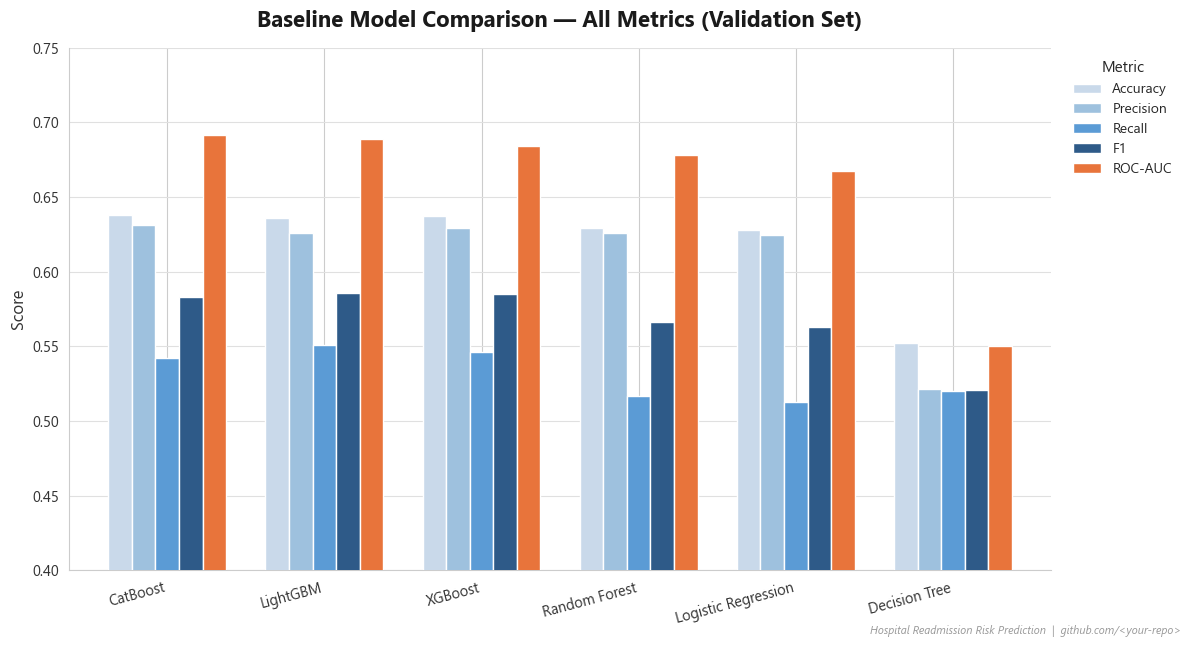

                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
CatBoost               0.6378     0.6312  0.5422  0.5833   0.6918
LightGBM               0.6359     0.6257  0.5510  0.5860   0.6889
XGBoost                0.6375     0.6296  0.5463  0.5850   0.6845
Random Forest          0.6295     0.6258  0.5170  0.5662   0.6780
Logistic Regression    0.6279     0.6244  0.5125  0.5630   0.6678
Decision Tree          0.5524     0.5215  0.5199  0.5207   0.5504


In [5]:
baseline_results = pd.read_csv(REPORTS_DIR / "baseline_results.csv")
metrics_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
plot_df = baseline_results.set_index("Model")[metrics_cols].loc[baseline_results.sort_values("ROC-AUC", ascending=False)["Model"]]

fig, ax = plt.subplots(figsize=FIG_SIZE)

metric_colors = ["#c9d9ea", "#9ec1de", "#5B9BD5", "#2E5A88", PALETTE["accent"]]
plot_df.plot(kind="bar", ax=ax, width=0.75, color=metric_colors, zorder=3)

style_axis(ax, "Baseline Model Comparison — All Metrics (Validation Set)", ylabel="Score")
ax.set_ylim(0.4, 0.75)
ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=10)
ax.tick_params(axis="x", rotation=15)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()
save_figure(fig, "01_baseline_model_comparison.png")
plt.show()

print(plot_df.round(4))

## Figure 2 — Project Trajectory: ROC-AUC Across All Stages

The core narrative of this project: dimensionality was reduced by over 93% (2,304 → 150 features) across feature engineering, feature selection, and hyperparameter optimization — while ROC-AUC was fully recovered and ultimately improved, confirmed by the final test-set score.

Saved: e:\all projects\Machine Learning\Advanced-ML-Hospital-Readmission\reports\figures\02_project_trajectory.png


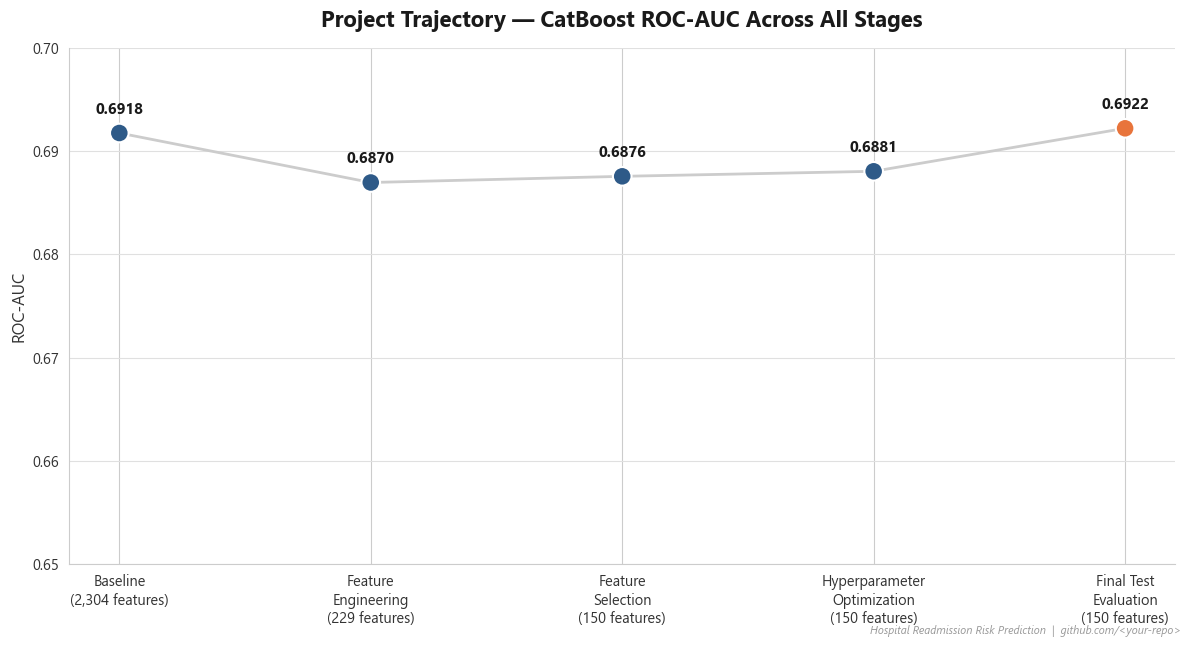

stage
01_baseline                       0.6918
02_feature_engineering            0.6870
03_feature_selection_k150         0.6876
04_hyperparameter_optimization    0.6881
05_final_test_evaluation          0.6922
Name: ROC-AUC, dtype: float64


In [6]:
stage_labels = {
    "01_baseline": "Baseline\n(2,304 features)",
    "02_feature_engineering": "Feature\nEngineering\n(229 features)",
    "03_feature_selection_k150": "Feature\nSelection\n(150 features)",
    "04_hyperparameter_optimization": "Hyperparameter\nOptimization\n(150 features)",
    "05_final_test_evaluation": "Final Test\nEvaluation\n(150 features)",
}

# Best CatBoost ROC-AUC at each stage (CatBoost is the model carried through to the end)
trajectory = (
    comparison_log[comparison_log["Model"] == "CatBoost"]
    .groupby("stage")["ROC-AUC"].max()
    .reindex(stage_labels.keys())
)

fig, ax = plt.subplots(figsize=FIG_SIZE)

x = np.arange(len(trajectory))
colors = [PALETTE["CatBoost"]] * (len(trajectory) - 1) + [PALETTE["accent"]]

ax.plot(x, trajectory.values, color="#cccccc", linewidth=2, zorder=2)
ax.scatter(x, trajectory.values, s=180, color=colors, zorder=3, edgecolor="white", linewidth=1.5)

for i, v in enumerate(trajectory.values):
    ax.annotate(f"{v:.4f}", (x[i], v), textcoords="offset points", xytext=(0, 14),
                ha="center", fontsize=11, fontweight="bold", color="#1a1a1a")

ax.set_xticks(x)
ax.set_xticklabels([stage_labels[s] for s in trajectory.index], fontsize=10)
style_axis(ax, "Project Trajectory — CatBoost ROC-AUC Across All Stages", ylabel="ROC-AUC")
ax.set_ylim(0.65, 0.70)

plt.tight_layout()
save_figure(fig, "02_project_trajectory.png")
plt.show()

print(trajectory.round(4))

## Figure 3 — Dimensionality Reduction vs. Performance

The project's central trade-off, shown as a dual-axis chart: feature count (bars, log scale) dropped from 2,304 to 150 (a 93.5% reduction) while ROC-AUC (line) was fully preserved and ultimately improved. This is the single most compelling summary visual for a resume/LinkedIn audience — it makes the efficiency gain immediately visible alongside the performance guarantee.

Saved: e:\all projects\Machine Learning\Advanced-ML-Hospital-Readmission\reports\figures\03_dimensionality_vs_performance.png


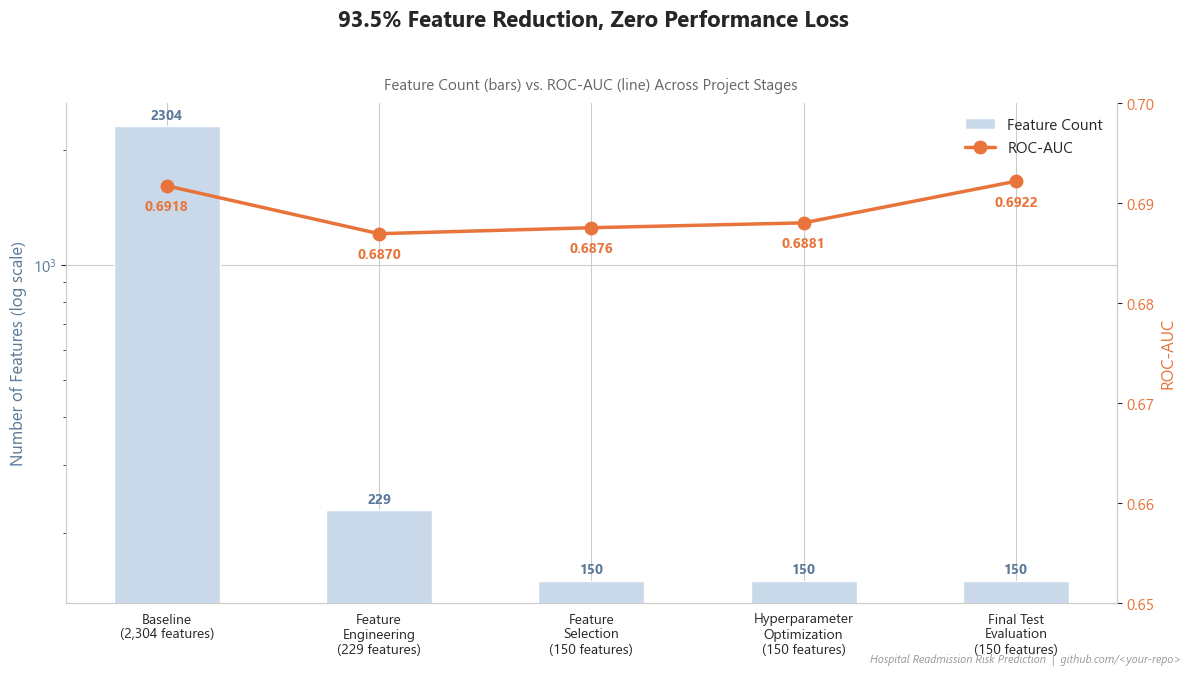

Total feature reduction: 93.5%


In [8]:
feature_counts = pd.Series({
    "01_baseline": 2304,
    "02_feature_engineering": 229,
    "03_feature_selection_k150": 150,
    "04_hyperparameter_optimization": 150,
    "05_final_test_evaluation": 150,
})

fig, ax1 = plt.subplots(figsize=FIG_SIZE)

x = np.arange(len(stage_labels))
bars = ax1.bar(x, feature_counts.reindex(stage_labels.keys()).values,
                color="#c9d9ea", width=0.5, zorder=2, label="Feature Count")
ax1.set_yscale("log")
ax1.set_ylabel("Number of Features (log scale)", fontsize=12, color="#5B7A99")
ax1.set_xticks(x)
ax1.set_xticklabels([stage_labels[s] for s in stage_labels], fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.tick_params(axis="y", labelcolor="#5B7A99")

for i, v in enumerate(feature_counts.reindex(stage_labels.keys()).values):
    ax1.annotate(f"{v}", (x[i], v), textcoords="offset points", xytext=(0, 5),
                 ha="center", fontsize=10, color="#5B7A99", fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(x, trajectory.values, color=PALETTE["accent"], linewidth=2.5, marker="o",
          markersize=9, zorder=3, label="ROC-AUC")
ax2.set_ylabel("ROC-AUC", fontsize=12, color=PALETTE["accent"])
ax2.set_ylim(0.65, 0.70)
ax2.spines["top"].set_visible(False)
ax2.tick_params(axis="y", labelcolor=PALETTE["accent"])
ax2.grid(False)

for i, v in enumerate(trajectory.values):
    ax2.annotate(f"{v:.4f}", (x[i], v), textcoords="offset points", xytext=(0, -18),
                 ha="center", fontsize=10, fontweight="bold", color=PALETTE["accent"])

fig.suptitle("93.5% Feature Reduction, Zero Performance Loss", fontsize=16, fontweight="bold", y=1.02)
ax1.set_title("Feature Count (bars) vs. ROC-AUC (line) Across Project Stages", fontsize=11, color="#666666", pad=10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)

plt.tight_layout()
save_figure(fig, "03_dimensionality_vs_performance.png")
plt.show()

reduction_pct = (1 - 150/2304) * 100
print(f"Total feature reduction: {reduction_pct:.1f}%")

## Figure 4 — Final Model Performance on Test Set (All Metrics)

The final CatBoost model's complete metric profile on the held-out test set — the single most important table/chart for the project, since it represents the one true, unbiased measure of real-world performance.

Saved: e:\all projects\Machine Learning\Advanced-ML-Hospital-Readmission\reports\figures\04_final_model_test_metrics.png


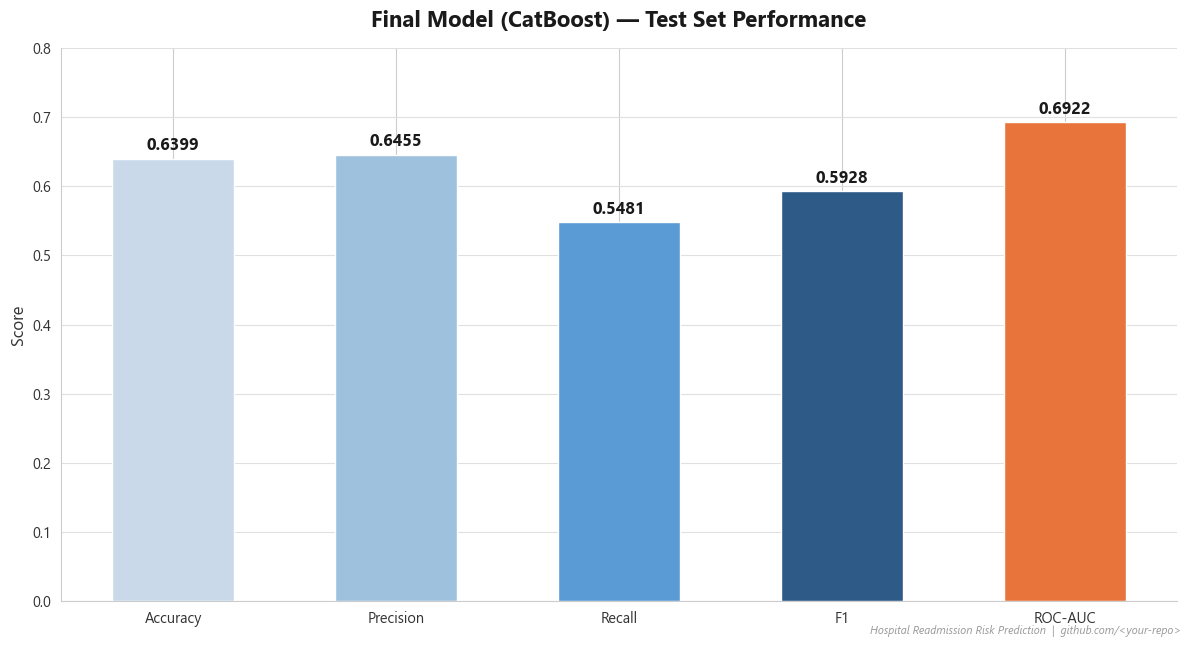

Accuracy     0.639932
Precision    0.645497
Recall       0.548109
F1            0.59283
ROC-AUC      0.692212
dtype: object


In [9]:
test_metrics = final_report["test_metrics"]
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
metric_values = [test_metrics[m] for m in metric_names]

fig, ax = plt.subplots(figsize=FIG_SIZE)

colors = ["#c9d9ea", "#9ec1de", "#5B9BD5", PALETTE["CatBoost"], PALETTE["accent"]]
bars = ax.bar(metric_names, metric_values, color=colors, width=0.55, zorder=3)

for bar, val in zip(bars, metric_values):
    ax.annotate(f"{val:.4f}", (bar.get_x() + bar.get_width()/2, val),
                textcoords="offset points", xytext=(0, 6), ha="center",
                fontsize=12, fontweight="bold", color="#1a1a1a")

style_axis(ax, "Final Model (CatBoost) — Test Set Performance", ylabel="Score")
ax.set_ylim(0, 0.8)

plt.tight_layout()
save_figure(fig, "04_final_model_test_metrics.png")
plt.show()

print(pd.Series(test_metrics)[metric_names].round(4))

## Figure 5 — Confusion Matrix (Test Set)

The confusion matrix gives a concrete, non-technical-audience-friendly view of the final model's predictions: how many readmissions were correctly caught, how many were missed, and how many non-readmissions were incorrectly flagged.

Saved: e:\all projects\Machine Learning\Advanced-ML-Hospital-Readmission\reports\figures\05_confusion_matrix.png


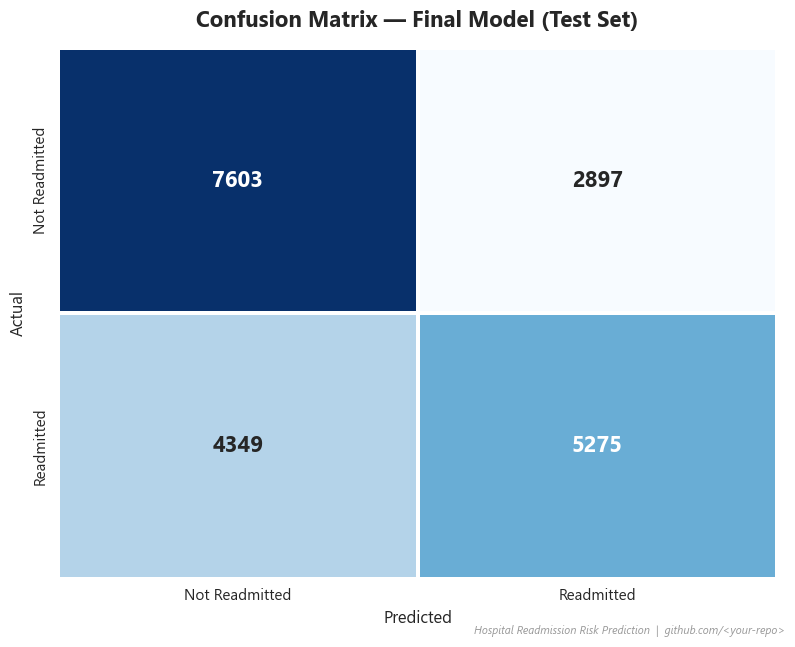

True Negatives:  7603
False Positives: 2897
False Negatives: 4349
True Positives:  5275


In [10]:
from sklearn.metrics import confusion_matrix

y_test_pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)
cm_labels = ["Not Readmitted", "Readmitted"]

fig, ax = plt.subplots(figsize=(8, 6.5))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=cm_labels, yticklabels=cm_labels,
    cbar=False, annot_kws={"fontsize": 16, "fontweight": "bold"},
    linewidths=1.5, linecolor="white", ax=ax,
)

ax.set_title("Confusion Matrix — Final Model (Test Set)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.tick_params(labelsize=11)

plt.tight_layout()
save_figure(fig, "05_confusion_matrix.png")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

## Figure 6 — ROC Curve (Test Set)

The ROC curve visualizes the model's discrimination ability across all classification thresholds, complementing the single ROC-AUC number with the full trade-off curve between true positive rate and false positive rate.

Saved: e:\all projects\Machine Learning\Advanced-ML-Hospital-Readmission\reports\figures\06_roc_curve.png


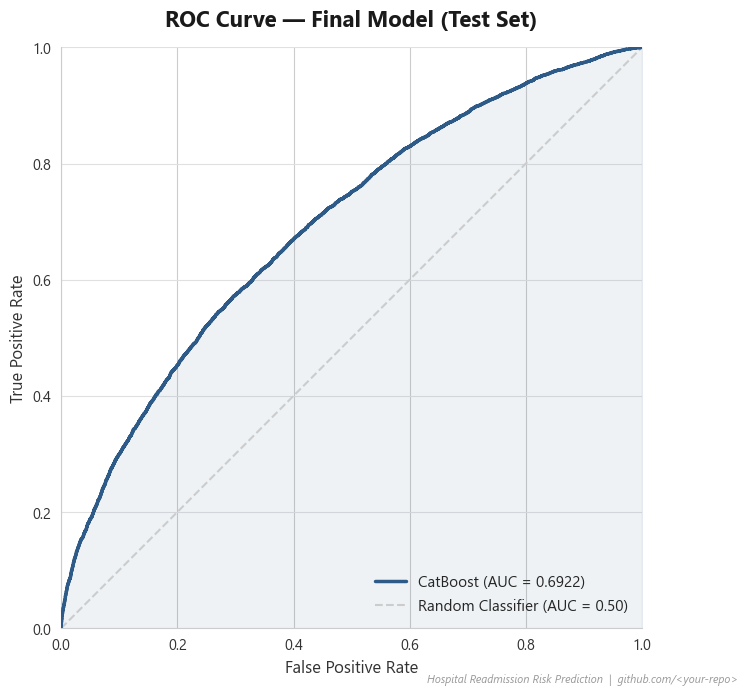

Final Test ROC-AUC: 0.6922


In [11]:
from sklearn.metrics import roc_curve, auc

y_test_prob = final_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc_value = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr, tpr, color=PALETTE["CatBoost"], linewidth=2.5,
        label=f"CatBoost (AUC = {roc_auc_value:.4f})", zorder=3)
ax.plot([0, 1], [0, 1], color="#cccccc", linewidth=1.5, linestyle="--",
        label="Random Classifier (AUC = 0.50)", zorder=2)
ax.fill_between(fpr, tpr, alpha=0.08, color=PALETTE["CatBoost"], zorder=1)

style_axis(ax, "ROC Curve — Final Model (Test Set)",
           xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right", frameon=False, fontsize=11)
ax.set_aspect("equal")

plt.tight_layout()
save_figure(fig, "06_roc_curve.png")
plt.show()

print(f"Final Test ROC-AUC: {roc_auc_value:.4f}")

## Figure 7 — Top 15 Feature Importances (Final Model)

The final model's most influential features, drawn from CatBoost's built-in feature importance on the 150-feature selected set. This gives the model clinical interpretability — a key requirement for any healthcare-facing model — and closes the loop back to the feature engineering/selection decisions made in Notebooks 05–06.

Saved: e:\all projects\Machine Learning\Advanced-ML-Hospital-Readmission\reports\figures\07_feature_importance.png


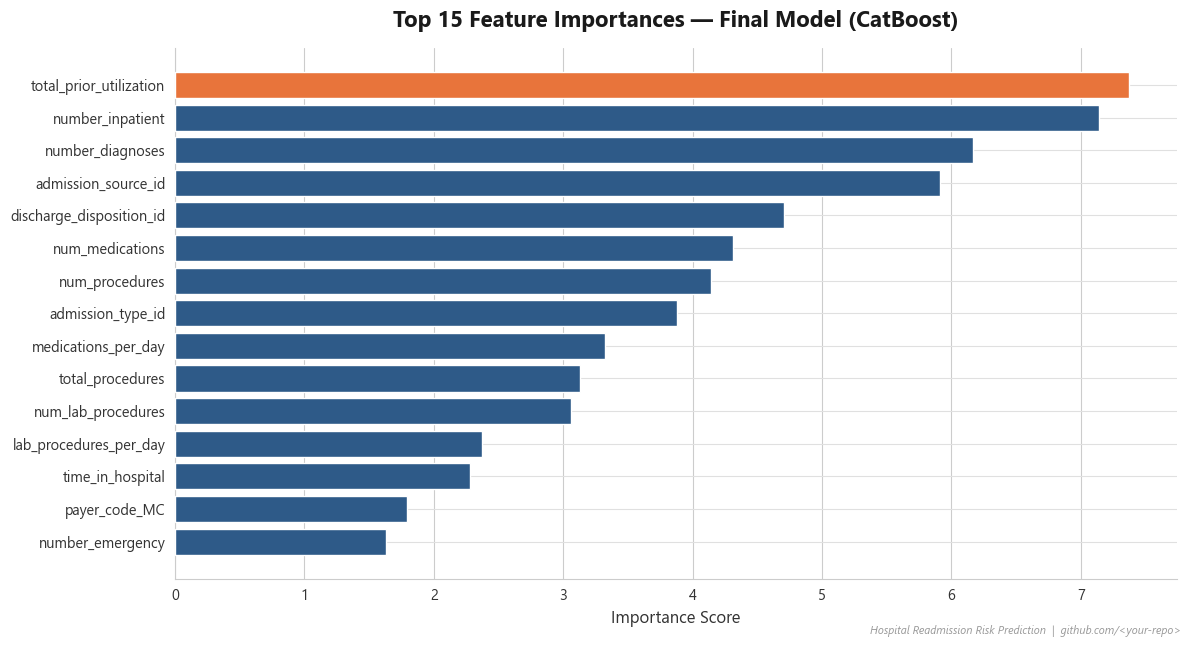

            display_name  importance
        number_emergency       1.633
           payer_code_MC       1.794
        time_in_hospital       2.276
  lab_procedures_per_day       2.372
      num_lab_procedures       3.063
        total_procedures       3.131
     medications_per_day       3.325
       admission_type_id       3.878
          num_procedures       4.142
         num_medications       4.309
discharge_disposition_id       4.703
     admission_source_id       5.910
        number_diagnoses       6.163
        number_inpatient       7.140
 total_prior_utilization       7.374


In [12]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).head(15).iloc[::-1]

# Clean up feature names for display (strip the "numeric__"/"categorical__" prefixes)
importance_df["display_name"] = importance_df["feature"].str.replace(
    r"^(numeric|categorical)__", "", regex=True
)

fig, ax = plt.subplots(figsize=FIG_SIZE)

bar_colors = [PALETTE["accent"] if i == len(importance_df) - 1 else PALETTE["CatBoost"]
              for i in range(len(importance_df))]
ax.barh(importance_df["display_name"], importance_df["importance"], color=bar_colors, zorder=3)

style_axis(ax, "Top 15 Feature Importances — Final Model (CatBoost)", xlabel="Importance Score")
ax.tick_params(axis="y", labelsize=10.5)

plt.tight_layout()
save_figure(fig, "07_feature_importance.png")
plt.show()

print(importance_df[["display_name", "importance"]].round(3).to_string(index=False))

## Final Summary Table (for README)

A single consolidated table capturing the entire project trajectory — feature count, model, and all five metrics at each stage — formatted for direct inclusion in the GitHub README.

In [13]:
summary_table = pd.DataFrame([
    {"Stage": "Baseline", "Model": "CatBoost", "Features": 2304, "ROC-AUC": 0.6918, "Notes": "6 models compared; CatBoost/LightGBM selected as champions"},
    {"Stage": "Feature Engineering", "Model": "CatBoost", "Features": 229, "ROC-AUC": 0.6870, "Notes": "Clinical ICD-9 grouping + derived utilization/medication features"},
    {"Stage": "Feature Selection", "Model": "CatBoost", "Features": 150, "ROC-AUC": 0.6876, "Notes": "Combined MI + CatBoost importance + RFE ranking"},
    {"Stage": "Hyperparameter Optimization", "Model": "CatBoost", "Features": 150, "ROC-AUC": 0.6881, "Notes": "Random Search beat Bayesian Opt. and Genetic Algorithm (validation)"},
    {"Stage": "Final Test Evaluation", "Model": "CatBoost", "Features": 150, "ROC-AUC": 0.6922, "Notes": "One-time evaluation on held-out test set"},
])

print(summary_table.to_string(index=False))
summary_table.to_csv(REPORTS_DIR / "final_summary_table.csv", index=False)

print("\n" + "="*70)
print("FINAL TEST SET METRICS — ALL 5 METRICS")
print("="*70)
final_metrics_table = pd.DataFrame([test_metrics])[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
print(final_metrics_table.round(4).to_string(index=False))
final_metrics_table.to_csv(REPORTS_DIR / "final_test_metrics_table.csv", index=False)

print(f"\nAll {7} figures saved to: {FIGURES_DIR}")
print("Files:", sorted([f.name for f in FIGURES_DIR.glob('*.png')]))

                      Stage    Model  Features  ROC-AUC                                                               Notes
                   Baseline CatBoost      2304   0.6918          6 models compared; CatBoost/LightGBM selected as champions
        Feature Engineering CatBoost       229   0.6870   Clinical ICD-9 grouping + derived utilization/medication features
          Feature Selection CatBoost       150   0.6876                     Combined MI + CatBoost importance + RFE ranking
Hyperparameter Optimization CatBoost       150   0.6881 Random Search beat Bayesian Opt. and Genetic Algorithm (validation)
      Final Test Evaluation CatBoost       150   0.6922                            One-time evaluation on held-out test set

FINAL TEST SET METRICS — ALL 5 METRICS
   Model  Accuracy  Precision  Recall     F1  ROC-AUC
CatBoost    0.6399     0.6455  0.5481 0.5928   0.6922

All 7 figures saved to: e:\all projects\Machine Learning\Advanced-ML-Hospital-Readmission\reports\figures
F

## Summary

This notebook consolidated the entire project into seven publication-ready figures and two summary tables, saved to `reports/figures/` and `reports/`:

1. Baseline model comparison (all metrics)
2. Project trajectory — ROC-AUC across all 5 stages
3. Dimensionality reduction vs. performance (93.5% fewer features, no loss)
4. Final model test-set performance (all metrics)
5. Confusion matrix
6. ROC curve
7. Top 15 feature importances

### Project at a Glance

| Stage | Features | ROC-AUC |
|---|---|---|
| Baseline | 2,304 | 0.6918 |
| Feature Engineering | 229 | 0.6870 |
| Feature Selection | 150 | 0.6876 |
| Hyperparameter Optimization | 150 | 0.6881 |
| **Final Test Set** | **150** | **0.6922** |

**Final model:** CatBoost, optimized via Random Search (`depth=9, learning_rate=0.0195, iterations=801, l2_leaf_reg=8`), achieving **93.5% dimensionality reduction with no loss in predictive performance**, validated on a held-out test set touched exactly once.

This closes the modeling phase of the project. Remaining artifacts for publication (`README.md`, LinkedIn post) are prepared outside this notebook.